# **MÓDULO 33 - Projeto Final de Modelos Avançados**

**Objetivo do Projeto:**

O objetivo deste projeto é aplicar os conceitos aprendidos nos módulos de conceitos avançados de modelagem para realizar uma segmentação de clientes utilizando o algoritmo de clustering K-Means. Ao final do projeto, você terá a oportunidade de consolidar seus conhecimentos em exploração de dados, pré-processamento, implementação e avaliação de modelos.

**Exploração de Dados:**

Inicie explorando o dataset fornecido, buscando entender as principais características das variáveis e a distribuição dos dados.

Realize análises descritivas, identifique padrões, e verifique a presença de valores ausentes ou inconsistências que precisem ser tratadas.

**Tratamento de Dados:**

Realize os tratamentos necessários como limpeza de dados, normalização ou padronização das variáveis, e, se necessário, a criação de variáveis derivadas.

Documente cada etapa do tratamento, explicando o motivo das escolhas feitas e como elas impactam no modelo.

**Implementação do Algoritmo K-Means:**

Aplique o algoritmo K-Means no dataset tratado. Defina o número de clusters (k).
Execute o algoritmo, ajuste os parâmetros conforme necessário, e documente o processo.

**Avaliação e Interpretação dos Resultados:**

Avalie a qualidade dos clusters gerados utilizando métricas adequadas.

Interprete os resultados, descrevendo as características de cada cluster e como eles podem ser utilizados para a segmentação de clientes.

Sugira aplicações práticas para os clusters identificados, como estratégias de marketing direcionadas ou personalização de ofertas.

**O dataset a ser utilizado neste projeto contém informações de 200 clientes, com os seguintes atributos:**

CustomerID: Identificador único atribuído a cada cliente.

Gender: Gênero do cliente.

Age: Idade do cliente.

Annual Income (k$): Renda anual do cliente em milhares de dólares.

Spending Score (1-100): Pontuação atribuída pelo shopping com base no
comportamento e padrão de gastos do cliente.

Notem que neste projeto vocês terão autonomia para criar os passos e justificar, sempre, os passos escolhidos.

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [2]:
base = pd.read_csv('Mall_Customers.csv', delimiter=',')

In [3]:
base

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [ ]:
# dados descritivos da base de dados
base.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [ ]:
# verificacao de dados - outliers
base.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [10]:
# padronizaçao dos dados para uso do KMeans
X = base[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
scaler = StandardScaler()
X_padronizado = scaler.fit_transform(X)

In [11]:
X_padronizado

array([[-1.42456879, -1.73899919, -0.43480148],
       [-1.28103541, -1.73899919,  1.19570407],
       [-1.3528021 , -1.70082976, -1.71591298],
       [-1.13750203, -1.70082976,  1.04041783],
       [-0.56336851, -1.66266033, -0.39597992],
       [-1.20926872, -1.66266033,  1.00159627],
       [-0.27630176, -1.62449091, -1.71591298],
       [-1.13750203, -1.62449091,  1.70038436],
       [ 1.80493225, -1.58632148, -1.83237767],
       [-0.6351352 , -1.58632148,  0.84631002],
       [ 2.02023231, -1.58632148, -1.4053405 ],
       [-0.27630176, -1.58632148,  1.89449216],
       [ 1.37433211, -1.54815205, -1.36651894],
       [-1.06573534, -1.54815205,  1.04041783],
       [-0.13276838, -1.54815205, -1.44416206],
       [-1.20926872, -1.54815205,  1.11806095],
       [-0.27630176, -1.50998262, -0.59008772],
       [-1.3528021 , -1.50998262,  0.61338066],
       [ 0.94373197, -1.43364376, -0.82301709],
       [-0.27630176, -1.43364376,  1.8556706 ],
       [-0.27630176, -1.39547433, -0.590

In [ ]:
# comparaçao de inertia e silhouette para escolher o k
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_padronizado)
    sil = silhouette_score(X_padronizado, labels)
    print(f'Número de clusters: {k}, inertia={kmeans.inertia_:.2f}, Silhouette Score: {sil:.3f}')

Número de clusters: 2, inertia=389.39, Silhouette Score: 0.335
Número de clusters: 3, inertia=295.21, Silhouette Score: 0.358
Número de clusters: 4, inertia=205.23, Silhouette Score: 0.404
Número de clusters: 5, inertia=168.25, Silhouette Score: 0.417
Número de clusters: 6, inertia=133.87, Silhouette Score: 0.427
Número de clusters: 7, inertia=117.01, Silhouette Score: 0.417
Número de clusters: 8, inertia=103.83, Silhouette Score: 0.409
Número de clusters: 9, inertia=92.35, Silhouette Score: 0.420
Número de clusters: 10, inertia=81.99, Silhouette Score: 0.397


O número de clusters mais adequado foi 6, pois apresentou o maior Silhouette Score (0.427), indicando melhor separação entre os grupos e maior coesão interna. Embora a inertia continue reduzindo com o aumento de k, esse comportamento é esperado e, por isso, a métrica silhouette foi mais útil para a decisão.

In [15]:
kmeans = KMeans(n_clusters=6, random_state=42, n_init=20)
base['clusters'] = kmeans.fit_predict(X_padronizado)
base.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),clusters
0,1,Male,19,15,39,2
1,2,Male,21,15,81,2
2,3,Female,20,16,6,5
3,4,Female,23,16,77,2
4,5,Female,31,17,40,5


In [16]:
centroides = kmeans.cluster_centers_
centroides

array([[ 0.22171558,  1.08322527, -1.29005223],
       [ 1.25472096, -0.24021294, -0.04399777],
       [-0.97602698, -1.32549704,  1.0371827 ],
       [-0.44191719,  0.99158305,  1.23950275],
       [-0.87309844, -0.11378508, -0.09358039],
       [ 0.47895722, -1.30822992, -1.19644353]])

In [18]:
#inversao dos centorides para a escala original dos dados, para melhor interpretacao dos resultados
centroides_padronizados = kmeans.cluster_centers_

centroides_originais = scaler.inverse_transform(centroides_padronizados)
centroides_originais

array([[41.93939394, 88.93939394, 16.96969697],
       [56.33333333, 54.26666667, 49.06666667],
       [25.25      , 25.83333333, 76.91666667],
       [32.69230769, 86.53846154, 82.12820513],
       [26.68421053, 57.57894737, 47.78947368],
       [45.52380952, 26.28571429, 19.38095238]])

In [20]:
# transformaçao dos centroides em um DataFrame para melhor visualizaçao
centroides_df = pd.DataFrame(
    centroides_originais,
    columns=['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
)

centroides_df

,Age,Annual Income (k$),Spending Score (1-100)
0,41.939394,88.939394,16.969697
1,56.333333,54.266667,49.066667
2,25.250000,25.833333,76.916667
3,32.692308,86.538462,82.128205
4,26.684211,57.578947,47.789474
5,45.523810,26.285714,19.380952


In [22]:
# Perfis pelo centroide
nomes_clusters = {
    0: 'Alta Renda, Baixo Gasto',
    1: 'Mais Velhos, Renda e Gastos Médios',
    2: 'Jovens, Baixa Renda, Alto Gasto',
    3: 'Alta Renda, Alto Gasto',
    4: 'Jovens, Renda e Gasto Médios',
    5: 'Baixa Renda, Baixo Gasto'
}

base['perfil_cluster'] = base['clusters'].map(nomes_clusters)

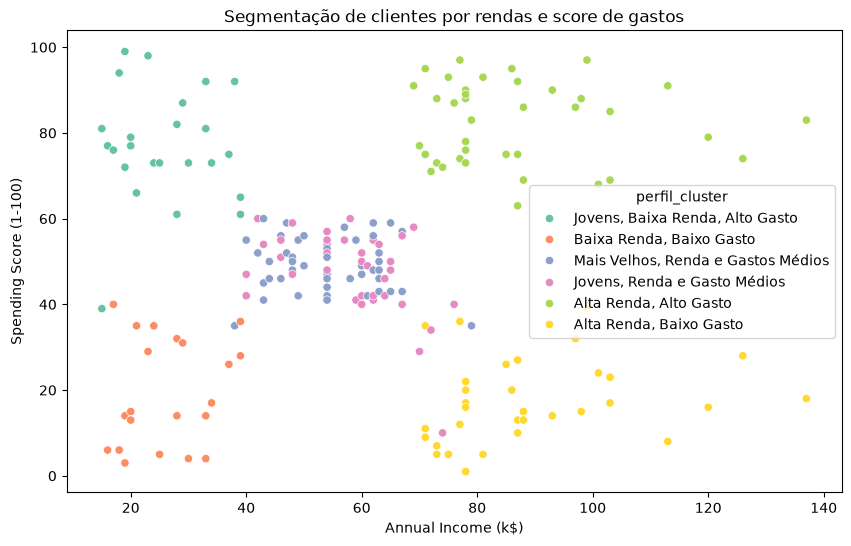

In [29]:
# Gráfico de dispersão dos clusters
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=base,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='perfil_cluster',
    palette='Set2'
)

plt.title('Segmentação de clientes por rendas e score de gastos')
plt.show()

In [26]:
# comparaçao da distribuiçao de genero por cluster
genero_por_cluster = pd.crosstab(
    base['clusters'],
    base['Gender'],
    normalize='index'
) * 100

genero_por_cluster.round(1)

Gender,Female,Male
clusters,,
0,42.4,57.6
1,57.8,42.2
2,58.3,41.7
3,53.8,46.2
4,63.2,36.8
5,61.9,38.1


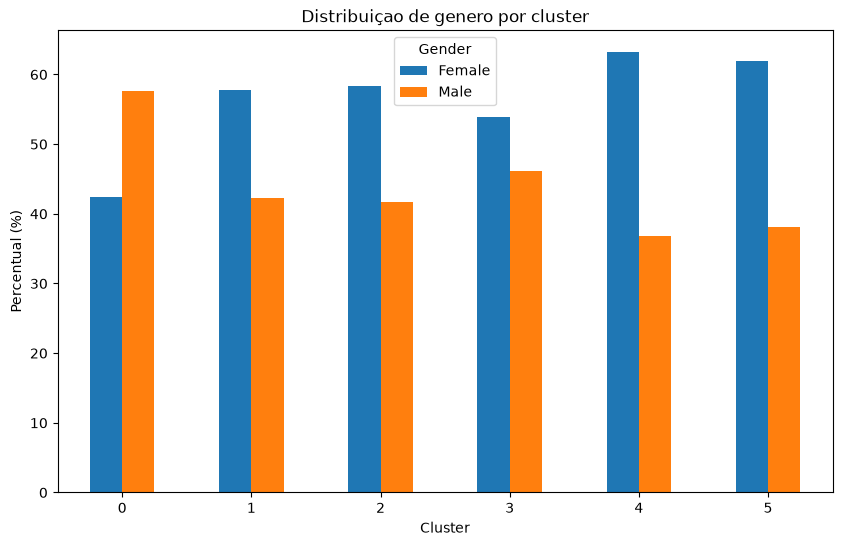

In [27]:
# grafico da distribuiçao de genero por cluster
genero_por_cluster.plot(kind='bar', figsize=(10, 6))

plt.title('Distribuiçao de genero por cluster')
plt.xlabel('Cluster')
plt.ylabel('Percentual (%)')
plt.xticks(rotation=0)
plt.legend(title='Gender')
plt.show()

Os clusters apresentam boa separação visual no gráfico de renda anual versus score de gastos. A segmentação evidencia perfis diferentes de clientes, como grupos com alta renda e alto gasto, alta renda e baixo gasto, baixa renda e alto gasto, além de clientes com renda e gasto médios. Isso indica que o modelo conseguiu capturar padrões relevantes de comportamento de consumo.